In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data Preprocessing and Data Profile

In [2]:
#read csv files **Make sure to change the file paths**

abm = pd.read_csv("abm.csv")
card = pd.read_csv("card.csv")
cheque = pd.read_csv("cheque.csv")
eft = pd.read_csv("eft.csv")
emt = pd.read_csv("emt.csv")
kyc_individual = pd.read_csv("kyc_individual.csv")
kyc_industry_codes = pd.read_csv("kyc_industry_codes.csv")
kyc_occupation_codes = pd.read_csv("kyc_occupation_codes.csv")
kyc_smallbusiness = pd.read_csv("kyc_smallbusiness.csv")
labels = pd.read_csv("labels.csv")
westernunion = pd.read_csv("westernunion.csv")
wire = pd.read_csv("wire.csv")
merchant_codes = pd.read_csv("mcc_codes.csv")

In [3]:
# data preview
print('✓ Loaded datasets successfully')
print(f'\nDataset sizes:')
print(f'  Abm transactions: {len(wire):,}')
print(f'  Wire transfers: {len(wire):,}')
print(f'  Western Union: {len(westernunion):,}')
print(f'  Card transactions: {len(card):,}')
print(f'  EFT transactions: {len(eft):,}')
print(f'  EMT transactions: {len(emt):,}')
print(f'  Individual KYC records: {len(kyc_individual):,}')
print(f'  Small Business KYC records: {len(kyc_smallbusiness):,}')

✓ Loaded datasets successfully

Dataset sizes:
  Abm transactions: 4,956
  Wire transfers: 4,956
  Western Union: 2,142
  Card transactions: 3,553,303
  EFT transactions: 1,070,698
  EMT transactions: 845,996
  Individual KYC records: 53,099
  Small Business KYC records: 8,311


In [4]:
#concat the card,cheque, eft, emt, abm, westernunion, wire dataset
eft['type'] = 'eft'
emt['type'] = 'emt'
abm['type'] = 'abm'
card['type'] = 'card'
cheque['type'] = 'cheque'
westernunion['type'] = 'westernunion'
wire['type'] = 'wire'
transactions = pd.concat([card, cheque, eft, emt, abm, westernunion, wire], ignore_index=True)

# merge transactions with labels
data = pd.merge(transactions, labels, on='customer_id', how='left')
transactions

,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,country,province,city,type,cash_indicator
0,CARD24110131109543,SYNID0102450742,13.35,D,2024-11-01 00:00:06,5812,1.0,CA,ON,NaN,card,NaN
1,CARD24110136178868,SYNID0105586872,6.05,D,2024-11-01 00:00:17,5968,1.0,NaN,NaN,other,card,NaN
2,CARD24110173783589,SYNID0107901560,81.40,C,2024-11-01 00:00:37,4816,0.0,CA,BC,NaN,card,NaN
3,CARD24110142566805,SYNID0107237475,3.20,D,2024-11-01 00:00:41,5814,0.0,CA,ON,MISSISSAUGA,card,NaN
4,CARD24110150346602,SYNID0109982946,356.03,D,2024-11-01 00:00:51,0,0.0,CA,AB,CALGARY,card,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5903328,2501312027222151,SYNID0200494373,664383.06,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903329,2501314427775083,SYNID0107588495,6720.80,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903330,2501313191709047,SYNID0108770535,20251.28,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903331,2501318829419846,SYNID0100253336,17410.89,D,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN


In [5]:
# organize the transaction datetime
transactions['transaction_datetime'] = pd.to_datetime(transactions['transaction_datetime'], format='mixed')
transactions['date'] = transactions['transaction_datetime'].dt.date

In [6]:
# calculate the account age for each customer

# fill missing onboard_date with the date of first transaction
transactions = transactions.sort_values(['customer_id','date'])
first_trans_date = transactions.groupby('customer_id')['date'].min()

kyc_individual['onboard_date'] = pd.to_datetime(kyc_individual['onboard_date']).fillna(
    kyc_individual['customer_id'].map(first_trans_date)
)
kyc_individual['account_age'] = (pd.to_datetime('2025-01-31') - kyc_individual['onboard_date']).dt.days

kyc_smallbusiness['onboard_date'] = pd.to_datetime(kyc_smallbusiness['onboard_date']).fillna(
    kyc_smallbusiness['customer_id'].map(first_trans_date)
)
kyc_smallbusiness['account_age'] = (pd.to_datetime('2025-01-31') - kyc_smallbusiness['onboard_date']).dt.days

kyc_age = pd.concat([kyc_individual[['customer_id','account_age']],kyc_smallbusiness[['customer_id','account_age']]],axis=0)
kyc_age = kyc_age.set_index('customer_id')['account_age']

## Feature Engineering

### Basic statistical features for each channel of transaction

These are summaries of different channels/types of transaction (e.g. wire, abm, eft...) for each account, including count, sum, average, standard deviation, minimum, maximum, median, coefficient variation, range and mean_to_max ratio. 

We assume these features can help us understand the statistical profile of transaction done by each account. The abnormal accounts might have very extreme values in certain measurement.

In [7]:
def create_transaction_features(df, prefix):
    """
    Create comprehensive features from transaction data
    """
    features = df.groupby('customer_id').agg({
    'amount_cad': ['count', 'sum', 'mean', 'std', 'min', 'max', 'median']
})  
    features.columns = [f'{prefix}_{col[1]}' for col in features.columns]
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_std'] / (features[f'{prefix}_mean'] + 1e-6)
    features[f'{prefix}_range'] = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_mean_to_max_ratio'] = features[f'{prefix}_mean'] / (features[f'{prefix}_max'] + 1e-6)
    features[f'{prefix}_std'] = features[f'{prefix}_std'].fillna(0)
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_coef_variation'].fillna(0)
    return features

wire_features = create_transaction_features(wire, 'wire')
wu_features = create_transaction_features(westernunion, 'wu')
card_features = create_transaction_features(card, 'card')
eft_features = create_transaction_features(eft, 'eft')
emt_features = create_transaction_features(emt, 'emt')

In [8]:
all_customers = set()
for df in [wire, westernunion, card, eft, emt]:
    all_customers.update(df['customer_id'].unique())

features = pd.DataFrame({'customer_id': list(all_customers)})
features = features.merge(wire_features, on='customer_id', how='left')
features = features.merge(wu_features, on='customer_id', how='left')
features = features.merge(card_features, on='customer_id', how='left')
features = features.merge(eft_features, on='customer_id', how='left')
features = features.merge(emt_features, on='customer_id', how='left')

features = features.fillna(0)

### Features about transaction volume

These are features about transaction volume for each account, including the count of total transaction, total transaction volume, average transaction volume, the maximum volume of single transacton, the max-to-average ratio of transaction, transaction standard deviation and consistency score.

We assume these features can help form a landscape of transaction volume. Abnormal accounts might have extreme volumes of transactions or high standard deviation and low consistency score.

In [9]:
count_cols = [col for col in features.columns if '_count' in col]
sum_cols = [col for col in features.columns if '_sum' in col]
mean_cols = [col for col in features.columns if '_mean' in col and '_to_' not in col]

# transaction counts, amount and average
features['total_trans_count'] = features[count_cols].sum(axis=1)
features['total_trans_volume'] = features[sum_cols].sum(axis=1)
features['avg_trans_volume'] = features['total_trans_volume'] / (features['total_trans_count'] + 1e-6)

# transaction max
max_cols = [col for col in features.columns if '_max' in col and 'ratio' not in col]
features['max_single_trans'] = features[max_cols].max(axis=1)
features['max_to_avg_ratio'] = features['max_single_trans'] / (features['avg_trans_volume'] + 1e-6)

# transaction consistency
std_cols = [col for col in features.columns if '_std' in col and 'to_' not in col]
features['overall_std'] = features[std_cols].mean(axis=1)
features['consistency_score'] = 1 / (features['overall_std'] + 1)

### Features about channel concentration

These features map how each account perform transactional activities through different channels, including channel diversity, concentration index and transaction precentile volume across channels

We assume that "Pass-Through" shell company will have extremely low channel diversity, a nearly 1 concentration index and high preference for a single channel, while smurfing accounts will have extremely high channel diversity, a very low concentration index and similar preference for all channels. 

In [10]:
# transaction channel diversity
features['channel_diversity'] = (features[count_cols] > 0).sum(axis=1)

# transaction channel concentration using Herfindahl-Hirschman Index. It falls between 1/n (perfectly diversified) and 1 (total concentration)
transaction_shares = features[count_cols].div(features['total_trans_count'] + 1e-6, axis=0)
features['channel_concentration'] = (transaction_shares ** 2).sum(axis=1)

# transaction amount concentration using Herfindahl-Hirschman Index. It falls between 1/n (perfectly diversified) and 1 (total concentration)
amount_shares = features[sum_cols].div(features['total_trans_volume'] + 1e-6, axis=0)
features['amount_concentration'] = (amount_shares ** 2).sum(axis=1)

In [11]:
# transaction volume per channel (percentage)
features['wire_preference'] = features['wire_sum'] / (features['total_trans_volume'] + 1e-6)
features['wu_preference'] = features['wu_sum'] / (features['total_trans_volume'] + 1e-6)
features['card_preference'] = features['card_sum'] / (features['total_trans_volume'] + 1e-6)
features['eft_preference'] = features['eft_sum'] / (features['total_trans_volume'] + 1e-6)
features['emt_preference'] = features['emt_sum'] / (features['total_trans_volume'] + 1e-6)

### Churn ratio in 7 Days

Churn ratio = outbound_7d/inbound_7d, meaning the ratio of total outbound and inbound amount in an account in 7 days. 

We assume that risky customers have churn ratio close to 1. If churn ratio is close to 1, it means the account is receiving and sending nearly the same amount of money, which could be a signal of money laundering.

In [12]:
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
v_trans['date'] = pd.to_datetime(v_trans['date'])

# calculate the net flow per account
v_trans['net_flow'] = v_trans.groupby('customer_id')['amount_cad'].cumsum()

In [13]:
# Calculate 7-Day Outbound Volume per Account

v_trans = v_trans.set_index('date')
outbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(upper=0).abs().rolling('7D').sum()
)

In [14]:
# Calculate 7-Day Inbound Volume per Account

inbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(lower=0).abs().rolling('7D').sum()
)

In [15]:
# Calculate churn ratio

v_trans['churn_ratio'] = outbound_7d / (inbound_7d + 1e-6)

In [16]:
# Calculate local Z-score of Churn Ratio for each account

# sum and sum of squared per account
stats = v_trans.groupby('customer_id')['churn_ratio'].agg(['sum', lambda x: (x**2).sum()]).reset_index()
stats.columns = ['customer_id', 'churn_sum', 'churn_sum_sq']

# User account age as denominator
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
stats['onboard_days'] = stats['customer_id'].map(kyc_age).clip(upper=window, lower=1)

# mean and std
stats['churn_mean'] = stats['churn_sum'] / (stats['onboard_days']+1e-6)
inner_val = (stats['churn_sum_sq'] / (stats['onboard_days']+1e-6)) - (stats['churn_mean']**2)
stats['churn_std'] = np.sqrt(inner_val.clip(lower=0)).fillna(0)

# Z-score
v_trans = v_trans.merge(stats[['customer_id', 'churn_mean', 'churn_std']], on='customer_id')
v_trans['churn_z_score'] = (v_trans['churn_ratio'] - v_trans['churn_mean']) / (v_trans['churn_std']+1e-6)

In [17]:
# construct flags for each transaction

# if churn_z_score is larger than 3, the amount outbound and inbound in 7d over time is very volatile. So it is abnormal and suspicious.
v_trans['is_anomaly'] = (v_trans['churn_z_score'] > 3).astype(int)

# if churn ratio is near 1, the amount outbound and inbound in 7d is nearly the same. So it is symmetric and suspicious
v_trans['is_symmetric'] = (v_trans['churn_ratio'].between(0.9, 1.1)).astype(int)

In [18]:
# Aggregate transaction-level flags to account level

# aggregate to account Level
churn_ratio = v_trans.groupby('customer_id').agg({
    'is_anomaly': 'sum',                 # Count of Z > 3 events
    'is_symmetric': 'sum',               # Count of 0.9-1.1 churn events
}).reset_index()

churn_ratio.columns = ['customer_id','churn_anomaly_count', 'churn_symmetry_count']

features = features.merge(churn_ratio,on='customer_id',how='left')

### __-to-income/sales ratio features

These features are adjusted towards the income of an individual or the sales of a small business. Income or sales alone is not persuasive enough because it varies by occupation or business type.

We assume that a abnomarlly high outbound/total volume/transaction count/average volume-to-income/sales ratio is suspicious.

In [19]:
# estimate incomes for individuals whose income's missing

# Assign 0 income to the unemployed,retired and student
fill_values = {
    'UNEMPLOYED': 0,
    'RETIRED': 0,
    'STUDENT': 0
}

for occupation, value in fill_values.items():
    mask = (kyc_individual['occupation_code'] == occupation) & (kyc_individual['income'].isna())
    kyc_individual.loc[mask, 'income'] = value

# In these missing observations, assign median income for the others
kyc_individual['income'] = kyc_individual['income'].fillna(
    kyc_individual.groupby('occupation_code')['income'].transform('median')
)

# fill individuals that don't have occupation information with 0 income
kyc_individual['income'] = kyc_individual['income'].fillna(0)

In [20]:
# estimate sales for small businesses whose sales's missing

# assign median sales for those missing values with same industry code
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(
    kyc_smallbusiness.groupby('industry_code')['sales'].transform('median')
)

# fill companies that don't have occupation information with 0 sales
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(0)

In [21]:
# compute total outbound amount for each account
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
total_outbound = v_trans.groupby('customer_id')['amount_cad'].apply(
    lambda x: x.clip(upper=0).abs().sum()
).reset_index(name='total_outbound_amount')
features = features.merge(total_outbound,on='customer_id',how='left')

In [22]:
# outbound_to_income ratio (for individuals)

outbound_income_ratio = total_outbound.merge(kyc_individual[['customer_id','income','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
outbound_income_ratio['onboard_days'] = outbound_income_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
outbound_income_ratio['income'] = outbound_income_ratio['onboard_days'] * outbound_income_ratio['income']/365
outbound_income_ratio['outbound_to_income_ratio'] = outbound_income_ratio['total_outbound_amount']/(outbound_income_ratio['income']+ 1e-6)
features = features.merge(outbound_income_ratio[['customer_id','income','outbound_to_income_ratio']],on='customer_id',how='left')

In [23]:
# outbound_to_sales ratio (for small businesses)

revenue_capacity_ratio = total_outbound.merge(kyc_smallbusiness[['customer_id','sales','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
revenue_capacity_ratio['onboard_days'] = revenue_capacity_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
revenue_capacity_ratio['sales'] = revenue_capacity_ratio['onboard_days'] * revenue_capacity_ratio['sales']/365
revenue_capacity_ratio['revenue_capacity_ratio'] = revenue_capacity_ratio['total_outbound_amount']/(revenue_capacity_ratio['sales']+1e-6)
features = features.merge(revenue_capacity_ratio[['customer_id','sales','revenue_capacity_ratio']],on='customer_id',how='left')

In [24]:
# total volume_to_income ratio
features['ttl_volume_to_income'] = features['total_trans_volume'] / (features['income'] + 1e-6)
# total volume_to_sales ratio
features['ttl_volume_to_sales'] = features['total_trans_volume'] / (features['sales'] + 1e-6)

# total transactions count to income ratio
features['trans_count_to_income'] = features['total_trans_count'] / (features['income'] + 1e-6)
# total transactions count to sales ratio
features['trans_count_to_sales'] = features['total_trans_count'] / (features['sales'] + 1e-6)

# average volume_to_income ratio
features['avg_volume_to_income'] = features['avg_trans_volume'] / (features['income'] + 1e-6)
# average volume_to_income ratio
features['avg_volume_to_sales'] = features['avg_trans_volume'] / (features['sales'] + 1e-6)


is_individual = features['customer_id'].isin(kyc_individual['customer_id'])
is_smallbusiness = features['customer_id'].isin(kyc_smallbusiness['customer_id'])
features.loc[is_individual,['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio']] = 0
features.loc[is_smallbusiness,['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio']] = 0

### Age and account age

We assume that an account with older account age and customers in older ages are less likely to commit money laundering

In [25]:
# add account age info to account profile
features = features.merge(kyc_age,on='customer_id',how='left')

In [26]:
# add customer age info to account profile
kyc_individual['age'] = ((pd.to_datetime('2025-1-31')-pd.to_datetime(kyc_individual.birth_date)).dt.days/365.25).fillna(0).astype(int)
features = features.merge(kyc_individual[['customer_id','age']],on='customer_id',how='left')
features['age'] = features['age'].replace(0,np.nan)

### Time Frequency features

Time frequency features measures the time energy and frequency energy of transactions for each account. It can help identify the rhythm or periodic behavior of transactions. We use a short-time fourier transformer to extract time frequency features.

The hypothesis tested in this work is that, the fundamental energy distribution characteristics of time-frequency representation of suspicious and non-suspicious entities will be different. For example, suspicous entities might witness a burst in transactions over a period of time and then remain dormant through the rest. Or, some accounts might be transfering similar volume of money on a certain day of the week. These suspicious behaviors can be captured by our time frequency features.

In [27]:
# Build stft transformer
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
daily_trans=v_trans.groupby(['customer_id','date'])['amount_cad'].sum().rename('net_flow_per_day').reset_index()
daily_trans

,customer_id,date,net_flow_per_day
0,SYNID0100000167,2024-11-03,42.05
1,SYNID0100000167,2024-11-08,-151.36
2,SYNID0100000167,2024-11-14,984.14
3,SYNID0100000167,2024-11-15,-97.07
4,SYNID0100000167,2024-12-01,-253.16
...,...,...,...
2792589,SYNID0200999998,2025-01-02,0.00
2792590,SYNID0200999998,2025-01-03,-42.73
2792591,SYNID0200999998,2025-01-06,-230.44
2792592,SYNID0200999998,2025-01-08,-38.79


In [28]:
# create a signal 

def get_customer_signal(daily, customer_id):
    s = (
        daily[daily['customer_id'] == customer_id]
        .set_index('date')
        .sort_index()['net_flow_per_day']
    )

    # Fill missing days with 0
    s = s.asfreq('D', fill_value=0)

    return s.values  # return the daily signal: an array of transactions each day

In [29]:
# use stft with sliding window
from scipy.signal import stft

# compute stft per customer
def compute_tf_matrix(signal,window_days,step_days=1):   # can set the window days to be 7,15,30
    """
    returns: |STFT| magnitude (time * frequency)
    """
    n = len(signal)
    nperseg = min(window_days, n)
    noverlap = min(nperseg - 1, nperseg - step_days)

    f, t, Zxx = stft(
        signal,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary=None
    )

    # Use magnitude
    tf_matrix = np.abs(Zxx)

    return f,t,tf_matrix  # shape: (freq_bins, time_bins)

In [30]:
# Plot heatmap of signal

def plot_tf_matrix(t,f,tf_matrix):
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f, tf_matrix)
    plt.title('Transaction Rhythms Over Time')
    plt.ylabel('Frequency (Cycles per Day)')
    plt.xlabel('Time (Days)')
    plt.colorbar(label='Magnitude (Intensity of Rhythm)')
    plt.grid(alpha=0.2)
    plt.show

Sample normalized stft representation

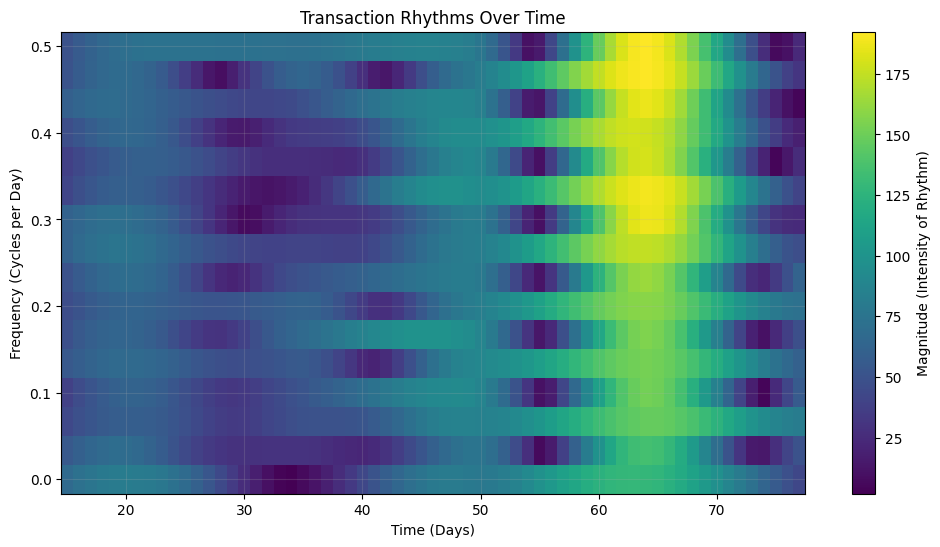

In [31]:
signal_nonfraud = get_customer_signal(daily_trans,'SYNID0100000485')   # SYNID0100000485 is non-fraud

# larger window sizes are good for detecting periodic smurfing transactions. smaller window sizes are good for detecting burst of transactions
f,t,tf_matrix = compute_tf_matrix(signal_nonfraud,30,1)  # set window days to 30 here to catch weekly cycles
plot_tf_matrix(t,f,tf_matrix)

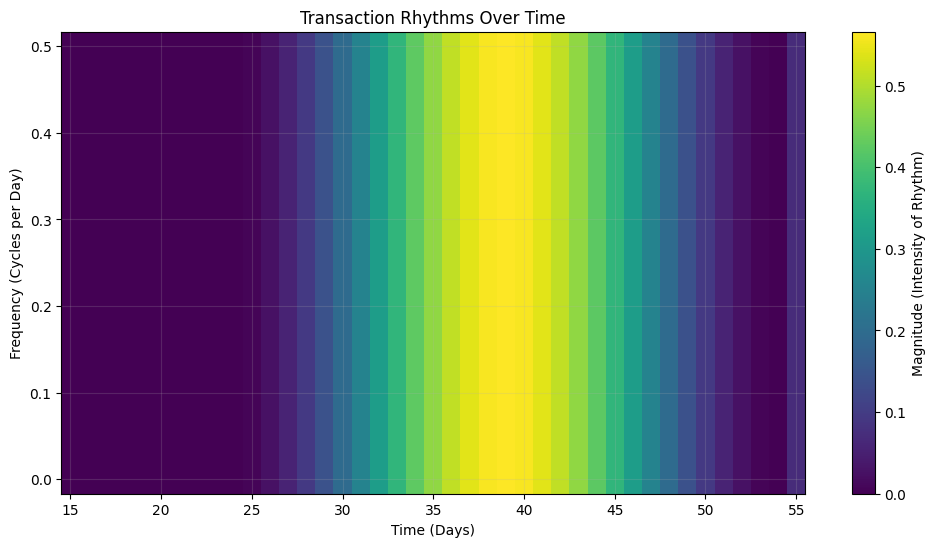

In [32]:
signal_fraud = get_customer_signal(daily_trans,'SYNID0101421130')   # SYNID0101421130 is fraud
f,t,tf_matrix = compute_tf_matrix(signal_fraud,30,1)  # set window days to 30
plot_tf_matrix(t,f,tf_matrix)

represent the tf matrix with features

In [33]:
# to cut time effectively, we compute the batch stft for all customers

def get_all_signals_matrix(df):
    """
    Returns: 
        signals_array: Numpy array (Days x Customers)
        customer_ids: List of customer IDs
    """
    print("Step 1: Creating Customer Signals Matrix...")
    
    # Pivot table
    matrix = df.pivot_table(
        index='date', 
        columns='customer_id', 
        values='net_flow_per_day', 
        fill_value=0
    )
    
    # Ensure daily frequency and fill missing days with 0
    matrix = matrix.asfreq('D', fill_value=0)
    
    return matrix.values, matrix.columns

In [34]:
def compute_batch_stft(signals_array, window_days, step_days=1):
    """
    Computes STFT for all customers simultaneously using vectorization.
    Input: 2D Array (Days x Customers)
    Output: 3D Tensor (Frequencies x TimeBins x Customers)
    """
    print("Step 2: Computing STFT for all customers...")
    
    nperseg = window_days
    noverlap = nperseg - step_days
    
    # axis=0 tells scipy to run down the time column for everyone
    f, t, Zxx = stft(
        signals_array, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        axis=0, 
        boundary=None
    )
    
    # Return the magnitude
    return np.abs(Zxx)

In [35]:
from scipy.stats import skew, kurtosis

def extract_all_tf_features(tf_tensor, customer_ids):

    print(f"1. Received Tensor Shape: {tf_tensor.shape}")
    
    num_customers = len(customer_ids)
    shape = tf_tensor.shape
    
    # auto-correlation strp: ensure shape is (Freq, Time, Customers)
    
    if shape[2] == num_customers:
        pass
        
    elif shape[0] == num_customers:
        tf_tensor = tf_tensor.transpose(1, 2, 0)
        
    elif shape[1] == num_customers:
        tf_tensor = tf_tensor.transpose(0, 2, 1)
        
    else:
        raise ValueError(f"Tensor shape {shape} does not match customer count {num_customers}!")

    print(f"2. Processing Corrected Tensor: {tf_tensor.shape}...")


    # Flatten Frequency and Time
    n_freqs, n_times, n_cust = tf_tensor.shape
    
    # ensure memory is contiguous for reshape
    tf_tensor = tf_tensor.copy()
    tf_flat = tf_tensor.reshape(-1, n_cust) 
    
    # caluclate the energy
    time_energy = tf_tensor.sum(axis=0) # Sum over Freq -> (Time, Cust)
    freq_energy = tf_tensor.sum(axis=1) # Sum over Time -> (Freq, Cust)
    
 
    # 1. average energy across the window --> the average transaction intensity
    tf_mean = tf_flat.mean(axis=0)

    # 2. variance of energy --> represent if there are extreme highs and lows in their transactions
    tf_var = tf_flat.var(axis=0)    

    # 3. asymmetry & tailedness --> anomalous bursts that deviate significantly from the norm
    tf_kurt = kurtosis(tf_flat, axis=0, fisher=False)
    mask_low_var = tf_var < 1e-10
    tf_kurt[mask_low_var] = 0
    
    # 4. measures sudden burst in volumes from one day to the next
    disc_time = np.abs(np.diff(tf_tensor, axis=1)).mean(axis=(0, 1))

    # 5. measures sudden change in rhythm of transactions
    disc_freq = np.abs(np.diff(tf_tensor, axis=0)).mean(axis=(0, 1))

    # 6. measure simultaneous shifts in time and frequency
    term1 = tf_tensor[:-1, :-1, :] 
    term2 = tf_tensor[1:, 1:, :]   
    term3 = tf_tensor[1:, :-1, :]  
    term4 = tf_tensor[:-1, 1:, :] 
    disc_tf = np.abs(term1 + term2 - term3 - term4).mean(axis=(0, 1))
    
    # 7. Entropy: unpredictability of the signal
    total_energy = tf_flat.sum(axis=0, keepdims=True) + 1e-12
    p = tf_flat / total_energy
    tf_entropy = -np.sum(p * np.log(p + 1e-12), axis=0)
    
    # 8. percentage of time that's inactive
    sparsity_time = (time_energy <= 1e-6).mean(axis=0)

    # 9. measures if the user lacks any dominant rhythm
    sparsity_freq = (freq_energy <= 1e-6).mean(axis=0)

    # 10. overall emptiness --> dormant accounts
    sparsity_tf   = (tf_flat <= 1e-6).mean(axis=0)


    data = {
        'tf_mean': tf_mean,
        'tf_var': tf_var,
        'tf_kurt': tf_kurt,
        'sparsity_time': sparsity_time,
        'sparsity_freq': sparsity_freq,
        'sparsity_tf': sparsity_tf,
        'disc_time': disc_time,
        'disc_freq': disc_freq,
        'disc_tf': disc_tf,
        'tf_entropy': tf_entropy
    }
    
    return pd.DataFrame(data, index=customer_ids)

In [36]:
# Window Days = 30
signals, cust_ids = get_all_signals_matrix(daily_trans)
tf_tensor30 = compute_batch_stft(signals, window_days=30, step_days=1)  # set window days to be 30
tf_features30 = extract_all_tf_features(tf_tensor30, cust_ids)
print('Window = 30, Done!')

Step 1: Creating Customer Signals Matrix...
Step 2: Computing STFT for all customers...
1. Received Tensor Shape: (16, 61410, 63)
2. Processing Corrected Tensor: (16, 63, 61410)...
Window = 30, Done!


In [37]:
features = features.merge(tf_features30,on='customer_id',how='left')

### Account activity days

These features include unique active days, account activity days and activity density days.

We assume that some risky accounts will have rather extreme values on these measurements.

In [38]:
# unique active days

unique_days = transactions.groupby('customer_id')['transaction_datetime'].apply(
    lambda x: x.dt.date.nunique()
).reset_index()
unique_days.columns = ['customer_id', 'unique_active_days']

In [39]:
active_features = transactions.groupby('customer_id').agg(
    first_transaction_date=('transaction_datetime', 'min'),
    last_transaction_date=('transaction_datetime', 'max')
)
active_features.rename(columns={
    'transaction_datetime_min': 'first_transaction_date',
    'transaction_datetime_max': 'last_transaction_date'
}, inplace=True)

# account activity days
active_features['account_activity_days'] = (
    active_features['last_transaction_date'] - 
    active_features['first_transaction_date']
).dt.days + 1

# activity density days
active_features = active_features.merge(unique_days,on='customer_id',how='left')
active_features['activity_density'] = (
    active_features['unique_active_days'] / 
    active_features['account_activity_days']
)

In [40]:
features = features.merge(active_features[['customer_id','unique_active_days','account_activity_days','activity_density']],on='customer_id',how='left')

### Transaction velocity

This records the transaction velocity of each account within 7 days.

We assume suspicous accounts have several extreme transaction velocity, either huge because of burst or layering behavior, or nearly zero because of scripted behavior. Thus, these accounts will have higher velocity variance.

In [41]:
# Calculate velocity variance
def calculate_velocity_variance(customer_transactions):
    customer_transactions = customer_transactions.sort_values('transaction_datetime')
    customer_transactions = customer_transactions.set_index('transaction_datetime')
    
    daily_counts = customer_transactions.resample('D').size()
    rolling_7day = daily_counts.rolling(window=7, min_periods=1).sum()
    velocity_variance = rolling_7day.var()
    
    return velocity_variance

# Apply to all customers
velocity_variance = transactions.groupby('customer_id').apply(
    calculate_velocity_variance,
    include_groups=False
).reset_index()
velocity_variance.columns = ['customer_id', 'velocity_variance_7day']

# Merge with features
features = features.merge(velocity_variance, on='customer_id', how='left')
features = features.assign(
    velocity_variance_7day=features['velocity_variance_7day'].fillna(0)
)

In [42]:
#features.to_csv('features.csv',index=False)

In [43]:
#features = pd.read_csv('features.csv')

## Data Pre-processing for model training

The rationale of this step is to prune our features to 20-30 in total before running an Isolation Forest to detect anomaly.

Because an Isolation Forest randomly selects variables to build its decision trees, feeding it all 60+ raw features migh dilute the model's focus. So we try to reduce the noise by selecting certain features through correlation matrix and supervised learning.

### Correlation matrix to reduce feature numbers for isolation forest

We want to reduce the number of features by identifying and pruning highly-correlated pairs

<Axes: >

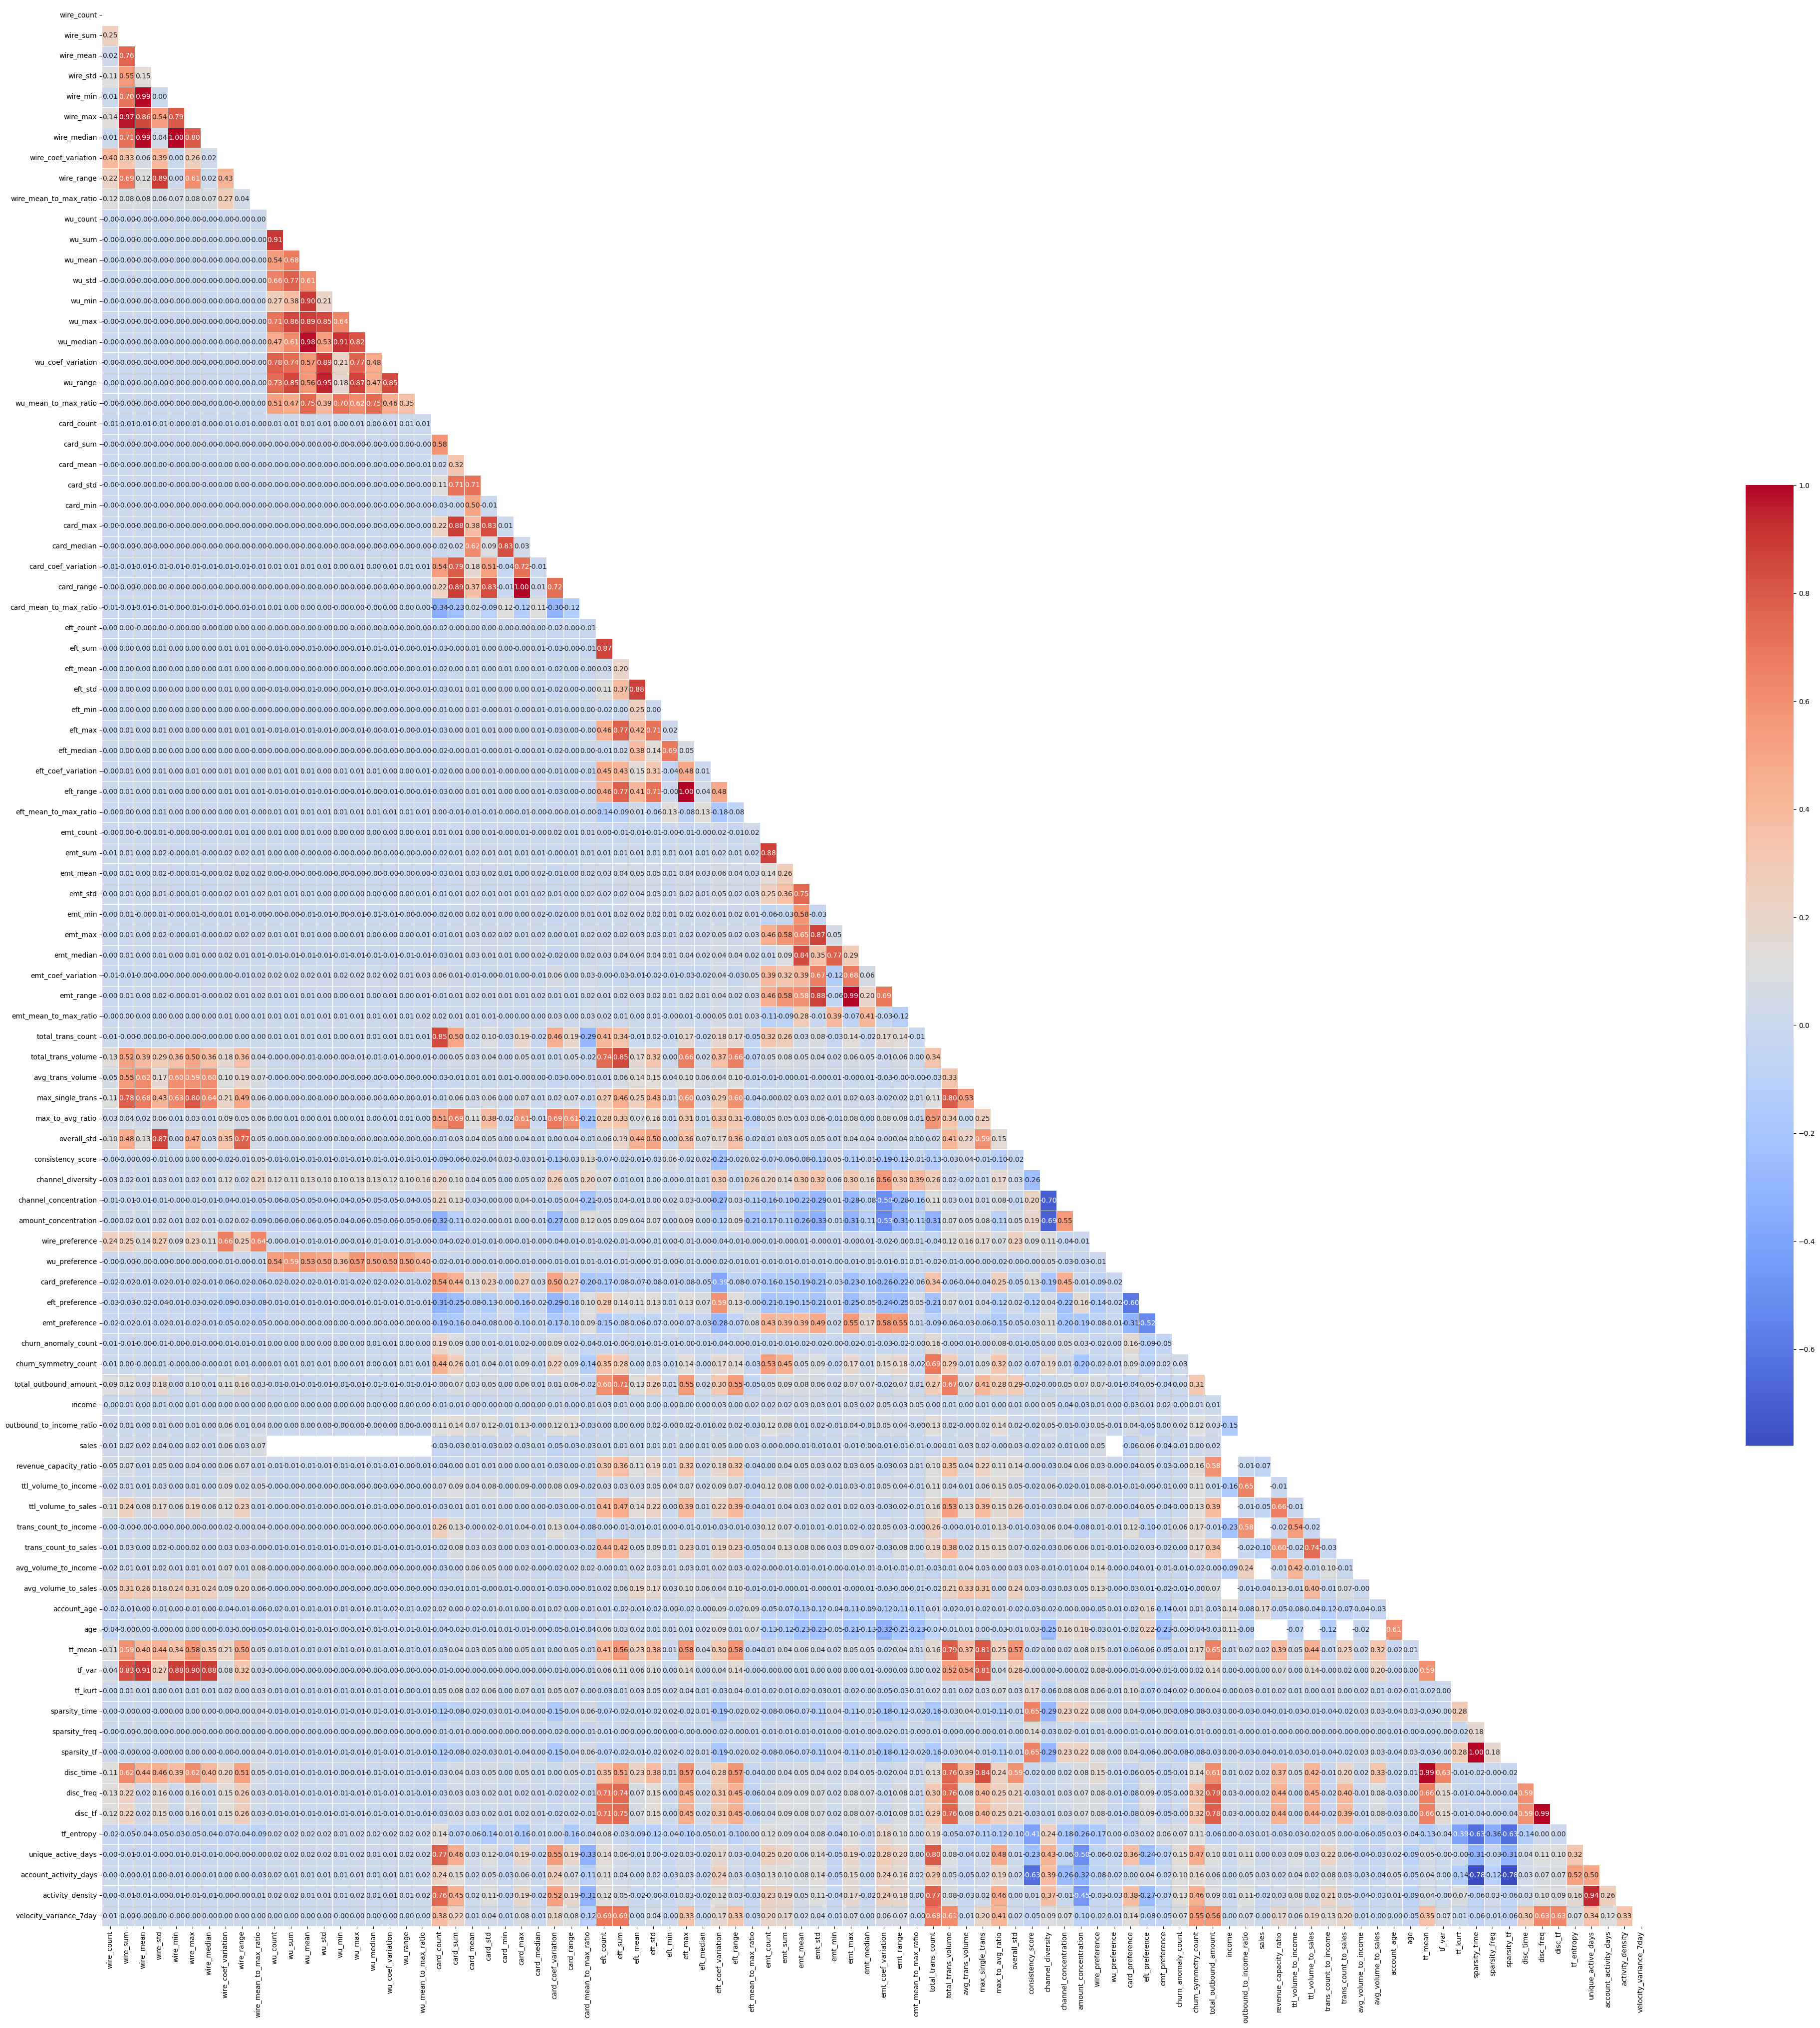

In [44]:
import seaborn as sns
import numpy as np

correlation_matrix = features.drop(columns='customer_id').corr()
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(50,50))
sns.heatmap(
    correlation_matrix,
    mask=mask,          # Apply the mask
    annot=True,
    cmap='coolwarm',    
    fmt=".2f",
    linewidths=0.5, 
    cbar_kws={"shrink": .5}
)

In [45]:
# check correlations > 0.8

upper_tri = correlation_matrix.abs().where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = upper_tri.unstack()
high_corr = corr_pairs[corr_pairs >= 0.8]
high_corr_sorted = high_corr.sort_values(ascending=False)
print(high_corr_sorted)

sparsity_tf         sparsity_time         1.000000
eft_range           eft_max               0.999812
card_range          card_max              0.999807
wire_median         wire_min              0.996799
disc_tf             disc_freq             0.993598
emt_range           emt_max               0.993419
wire_median         wire_mean             0.992259
disc_time           tf_mean               0.992116
wire_min            wire_mean             0.988299
wu_median           wu_mean               0.984658
wire_max            wire_sum              0.972018
wu_range            wu_std                0.949508
activity_density    unique_active_days    0.943713
wu_median           wu_min                0.911881
tf_var              wire_mean             0.906879
wu_sum              wu_count              0.905511
tf_var              wire_max              0.899173
wu_min              wu_mean               0.895177
wu_coef_variation   wu_std                0.893038
wire_range          wire_std   

In [46]:
# drop one of the features in these pairs
features_reduced = features.drop(columns=['sparsity_time','eft_max','card_max','wire_median','disc_freq','emt_max','tf_mean','wire_min',
                                          'wu_median','wire_max','wu_range','unique_active_days','wu_median','tf_var','wu_count','wu_min',
                                          'wu_coef_variation','wire_range','card_range','eft_mean','emt_count','emt_range','eft_count','overall_std',
                                          'eft_sum','emt_median','max_single_trans','card_max','wu_max','card_median','card_count'])

<Axes: >

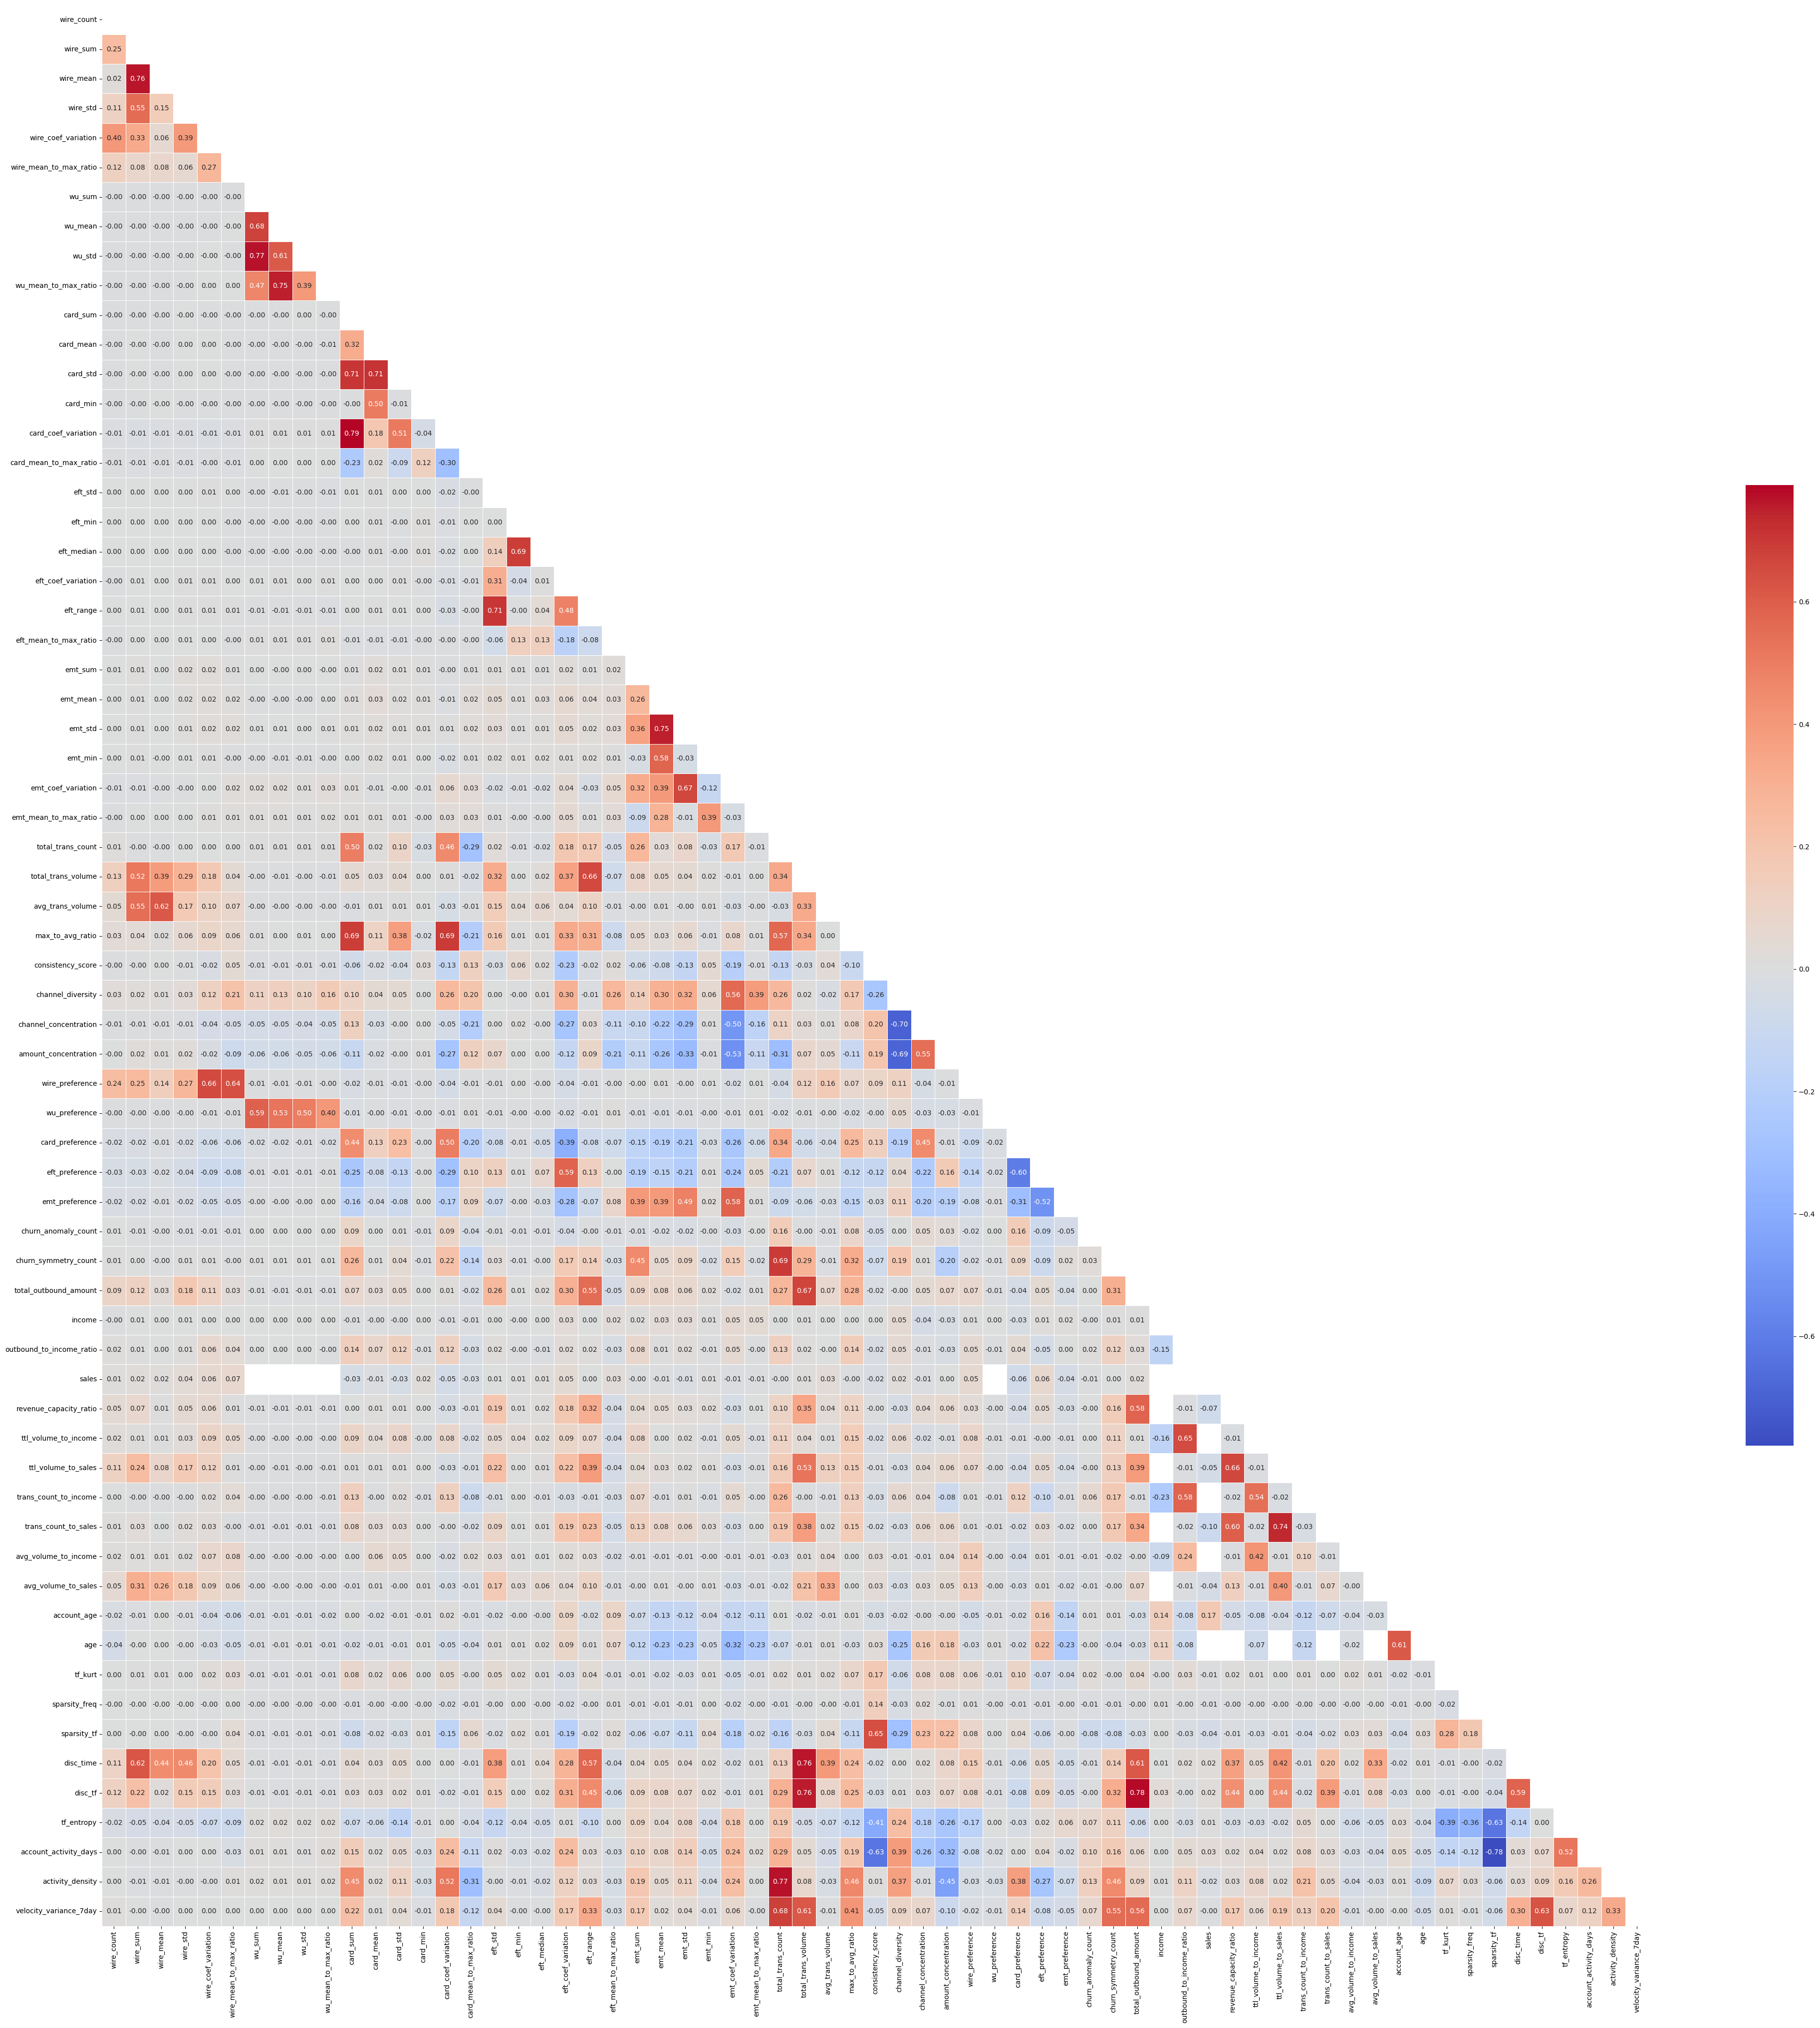

In [47]:
# recheck the correlation matrix

correlation_matrix_reduced = features_reduced.drop(columns='customer_id').corr()
mask = np.zeros_like(correlation_matrix_reduced, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(50,50))
sns.heatmap(
    correlation_matrix_reduced,
    mask=mask,          # Apply the mask
    annot=True,
    cmap='coolwarm',    
    fmt=".2f",
    linewidths=0.5, 
    cbar_kws={"shrink": .5}
)

### Supervised learning to filter features for isolation forest

We are utilizing XGBoost as another selection mechanism to solve the 'swamping effect' inherent in high-dimensional anomaly detection. By temporarily treating our data as a supervised problem and training XGBoost on historical labelled suspicious activities, we can extract only high-impact feature sets to train our unsupervised Isolation Forest.

In [48]:
# merge with the labels for supervised learning
features_reduced_new = features_reduced.merge(labels,on='customer_id',how='right')

# split our data into individual and business features
individual_features = features_reduced_new[features_reduced_new['customer_id'].isin(kyc_individual['customer_id'])].drop(columns=['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio'])
business_features = features_reduced_new[features_reduced_new['customer_id'].isin(kyc_smallbusiness['customer_id'])].drop(columns=['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio'])

#### Most Important features for individuals

In [49]:
from xgboost import XGBClassifier

X = individual_features.drop(columns=['customer_id','label']) 
y = individual_features['label']

# Calculate the ratio of normal accounts to flagged to handle the extreme imbalance
scale_weight = len(y[y == 0]) / len(y[y == 1])

# Initialize XGBoost with the scale_pos_weight to force it to care about the rare flagged
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    max_depth=4,        # shallow to prevent overfitting
    random_state=42
)

# Train the model
xgb_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

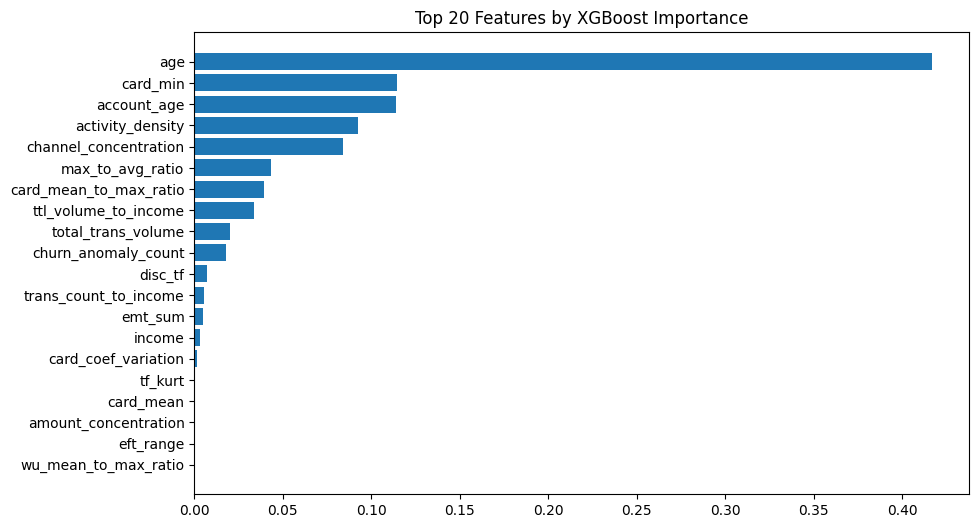

In [50]:
# feature importances for features selection
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

individual_important_features = feature_importance_df['Feature'].head(20).reset_index().drop(columns='index')

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by XGBoost Importance')
plt.show()

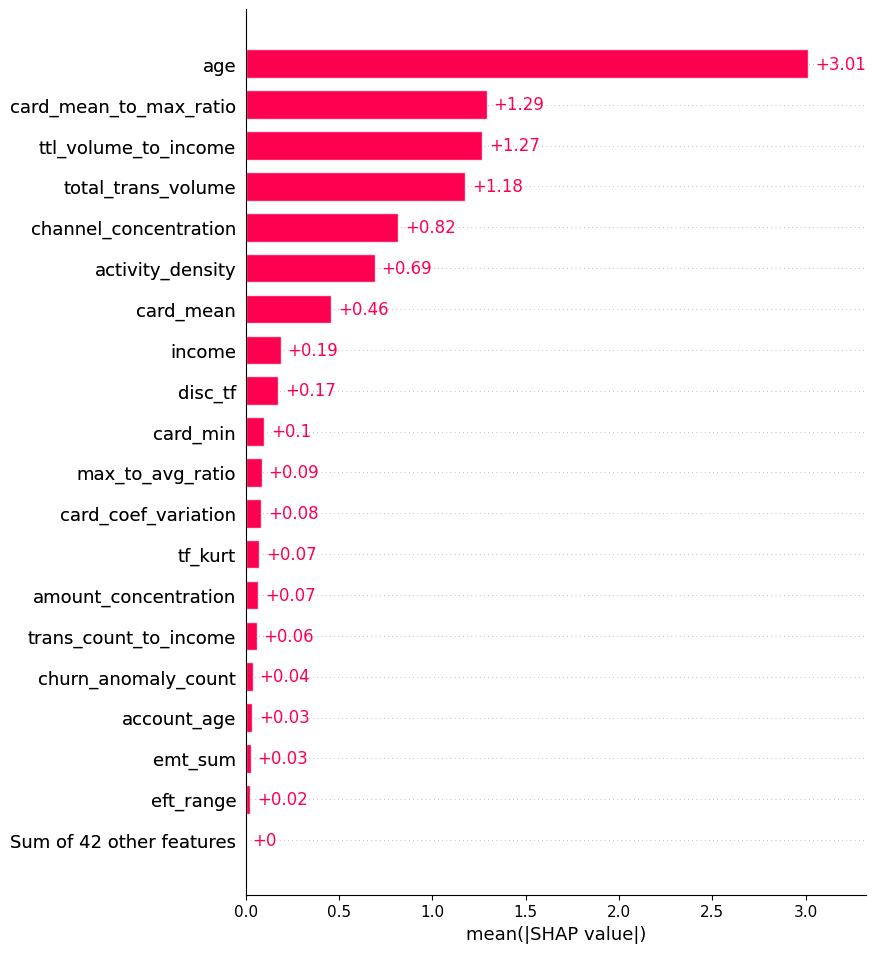

,feature_name,shap_score
51,age,3.013275
15,card_mean_to_max_ratio,1.289558
47,ttl_volume_to_income,1.267300
29,total_trans_volume,1.175768
34,channel_concentration,0.817257
...,...,...
53,sparsity_freq,0.000000
55,disc_time,0.000000
57,tf_entropy,0.000000
58,account_activity_days,0.000000


In [51]:
# double check with shap value for a more comprehensive feature selection
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

raw_shap_matrix = shap_values.values
global_shap_importance = np.abs(raw_shap_matrix).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature_name': X.columns,
    'shap_score': global_shap_importance
})
feature_importance_df = feature_importance_df.sort_values(by='shap_score', ascending=False)
feature_importance_df

Here's the list of features for isolation forest

In [52]:
# Combine the features selected from feature importance and SHAP
individual_important_features = pd.concat([individual_important_features['Feature'],feature_importance_df['feature_name'].head(20)],axis=0).drop_duplicates()
individual_important_features

0                        age
1                   card_min
2                account_age
3           activity_density
4      channel_concentration
5           max_to_avg_ratio
6     card_mean_to_max_ratio
7       ttl_volume_to_income
8         total_trans_volume
9        churn_anomaly_count
10                   disc_tf
11     trans_count_to_income
12                   emt_sum
13                    income
14       card_coef_variation
15                   tf_kurt
16                 card_mean
17      amount_concentration
18                 eft_range
19      wu_mean_to_max_ratio
dtype: object

In [53]:
individual_important_features=individual_important_features.tolist()

#### Most important features for small businesses

In [54]:
from xgboost import XGBClassifier

X = business_features.drop(columns=['customer_id','label']) 
y = business_features['label']

# Calculate the ratio of normal accounts to flagged to handle the extreme imbalance
scale_weight = len(y[y == 0]) / len(y[y == 1])

# Initialize XGBoost with the scale_pos_weight to force it to care about the rare flagged
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    max_depth=4,        # shallow to prevent overfitting
    random_state=42
)

# Train the model
xgb_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

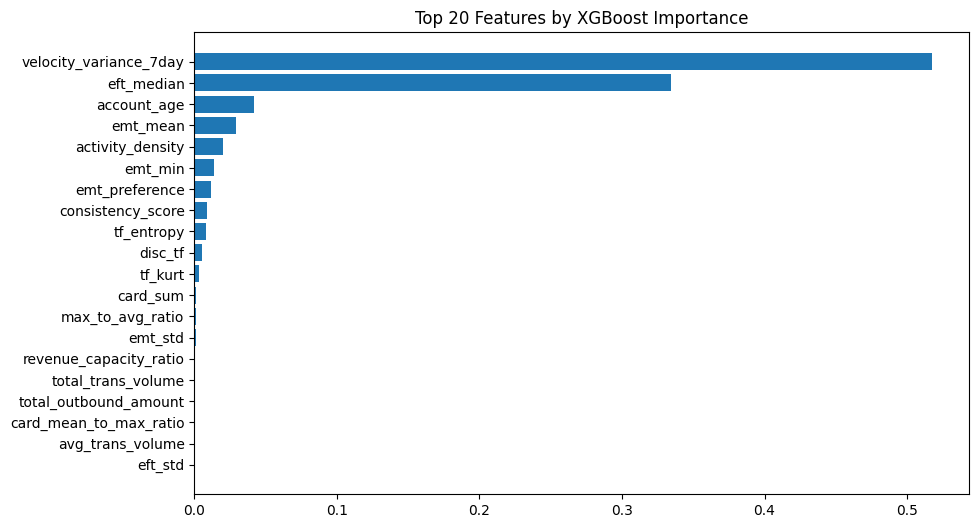

In [55]:
# feature importances for features selection
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

business_important_features = feature_importance_df['Feature'].head(20).reset_index().drop(columns='index')

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by XGBoost Importance')
plt.show()

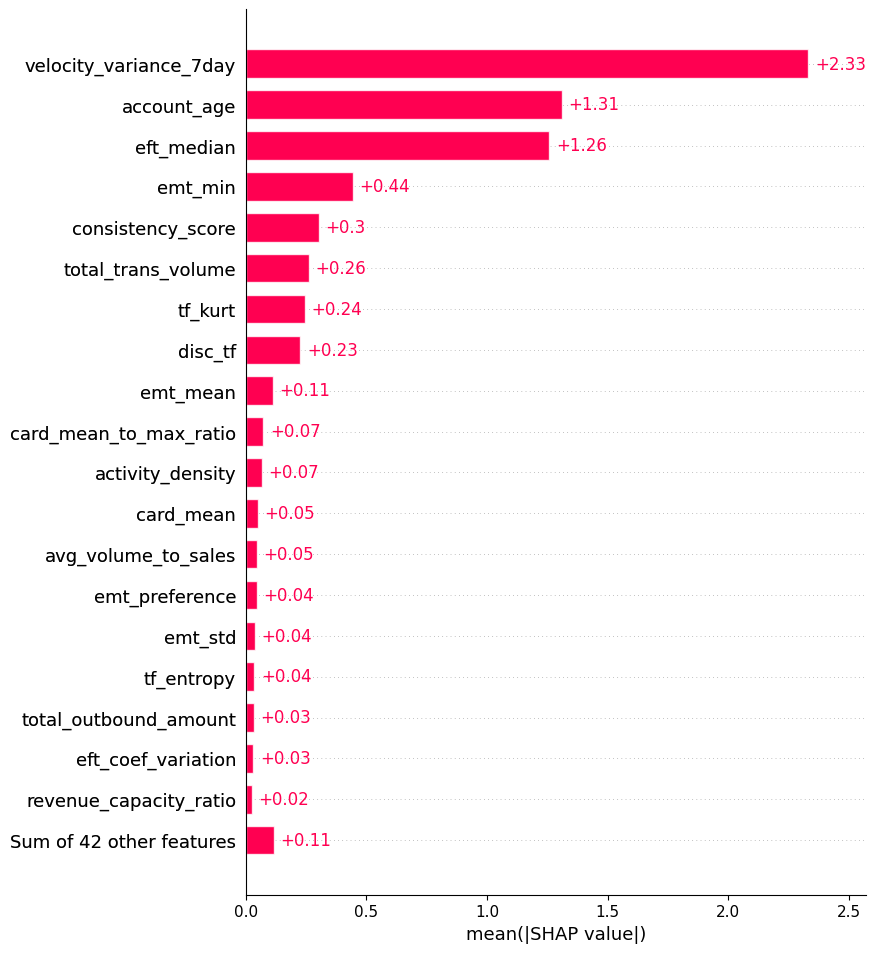

,feature_name,shap_score
60,velocity_variance_7day,2.330817
50,account_age,1.309097
18,eft_median,1.257784
25,emt_min,0.442257
32,consistency_score,0.301628
...,...,...
48,trans_count_to_sales,0.000000
51,age,0.000000
54,sparsity_tf,0.000000
53,sparsity_freq,0.000000


In [56]:
# shap value for feature selection
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

raw_shap_matrix = shap_values.values
global_shap_importance = np.abs(raw_shap_matrix).mean(axis=0)

# 3. Create a DataFrame to map the scores back to your feature names
feature_importance_df = pd.DataFrame({
    'feature_name': X.columns,
    'shap_score': global_shap_importance
})
feature_importance_df = feature_importance_df.sort_values(by='shap_score', ascending=False)
feature_importance_df

In [57]:
# combine the top 20 features from feature importance and the top 20 from SHAP
business_important_features = pd.concat([business_important_features['Feature'],feature_importance_df['feature_name'].head(20)],axis=0).drop_duplicates().tolist()
business_important_features

['velocity_variance_7day',
 'eft_median',
 'account_age',
 'emt_mean',
 'activity_density',
 'emt_min',
 'emt_preference',
 'consistency_score',
 'tf_entropy',
 'disc_tf',
 'tf_kurt',
 'card_sum',
 'max_to_avg_ratio',
 'emt_std',
 'revenue_capacity_ratio',
 'total_trans_volume',
 'total_outbound_amount',
 'card_mean_to_max_ratio',
 'avg_trans_volume',
 'eft_std',
 'card_mean',
 'avg_volume_to_sales',
 'eft_coef_variation']

## Isolation Forest Training

The rationale behind deploying an Isolation Forest for AML machine learning lies in its approach to anomaly identification. It is an unsupervised algorithm that  can identify the 'unknown unknowns' and isolate data points that are mathematically few and different. It matches with our goal to identify illicit financial activities—such as rapid layering bursts, unnatural transaction velocity, or extreme channel concentration—naturally that deviate from dense clusters of typical banking behavior.

Isolation Forest works by:
1. Randomly selecting features and split values
2. Creating isolation trees
3. Anomalies are isolated earlier (shorter path length)
4. Anomaly score based on average path length across trees

In [58]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

In [59]:
individual_features = features[features['customer_id'].isin(kyc_individual['customer_id'])].drop(columns=['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio'])
business_features = features[features['customer_id'].isin(kyc_smallbusiness['customer_id'])].drop(columns=['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio'])

### Isolation Forest for individual accounts

#### Model Training

In [60]:
cols_to_keep = ['customer_id'] + individual_important_features
individual_features_selected = individual_features[cols_to_keep].copy()
X = individual_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 20
Customers: 52,677

Missing values: 3493
Infinite values: 0


In [61]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.3s remaining:    3.2s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.3s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

#### Results

In [62]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

individual_features_selected['raw_anomaly_score'] = raw_scores
individual_features_selected['is_alerted'] = is_alerted
individual_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
individual_risk_score = individual_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [63]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (individual_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (individual_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (individual_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (individual_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
individual_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(individual_risk_score['risk_level'].value_counts(normalize=True) * 100)
individual_risk_score


Distribution of Risk Levels:
risk_level
Low       79.998861
Medium    15.000854
High       5.000285
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
13994,SYNID0109825639,100.000000,-0.215258,1,High
4990,SYNID0103550907,98.959210,-0.211520,1,High
53329,SYNID0103491795,98.958205,-0.211516,1,High
1598,SYNID0101511348,98.323139,-0.209235,1,High
30101,SYNID0105411519,97.049138,-0.204658,1,High
...,...,...,...,...,...
44828,SYNID0101886667,0.553048,0.141978,0,Low
52354,SYNID0105031347,0.355745,0.142687,0,Low
6016,SYNID0100777620,0.324526,0.142799,0,Low
8169,SYNID0101272513,0.057074,0.143760,0,Low


#### Model performance

In [64]:
# Check the accuracy of isolation forest on our labelled data

nonfraud_customers = labels[labels['label'] == 0]['customer_id'].unique()
fraud_customers = labels[labels['label'] == 1]['customer_id'].unique()
print(individual_risk_score[individual_risk_score['customer_id'].isin(fraud_customers)])
print('\n')

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
130    SYNID0107832828       38.319666           0.006311           0   
23583  SYNID0107334515       33.252380           0.024514           0   
46573  SYNID0105593361       26.441094           0.048982           0   
56975  SYNID0101421130       25.366907           0.052841           0   
56007  SYNID0100957188       24.381446           0.056381           0   
43910  SYNID0107464935       22.820769           0.061987           0   

      risk_level  
130       Medium  
23583     Medium  
46573     Medium  
56975     Medium  
56007     Medium  
43910        Low  




at least many of our suspicious (labelled 1) accounts are labelled as medium-level risk

#### Model explanation

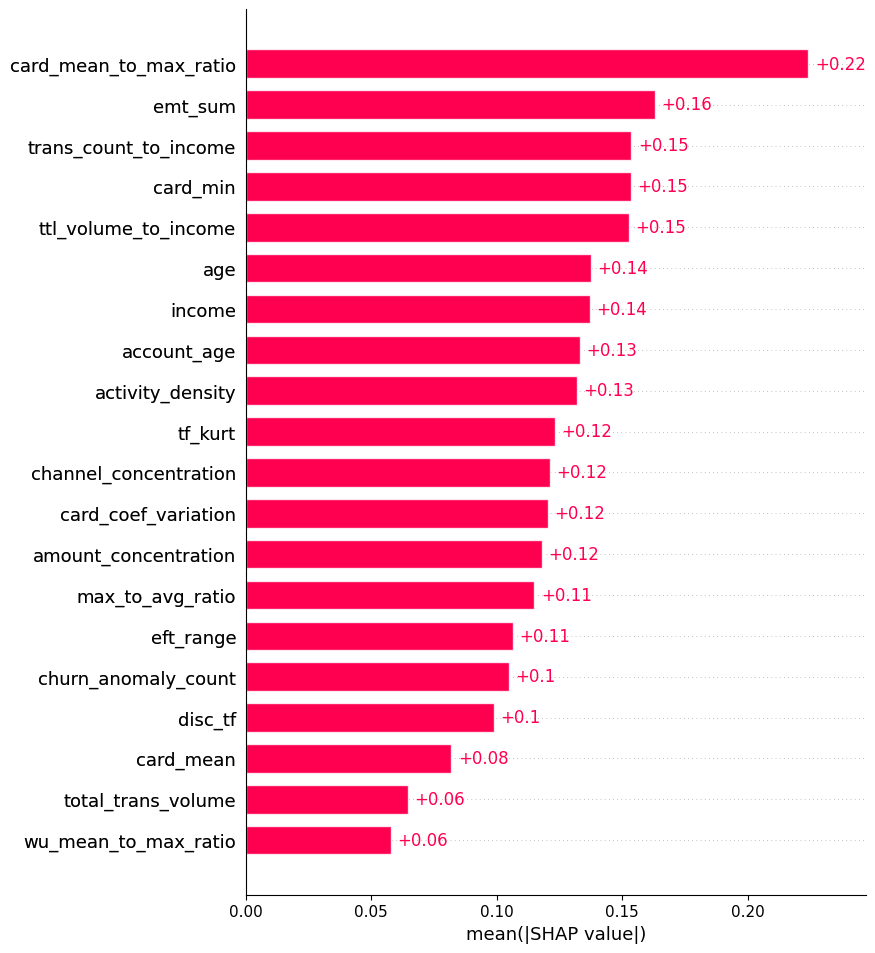

In [65]:
# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

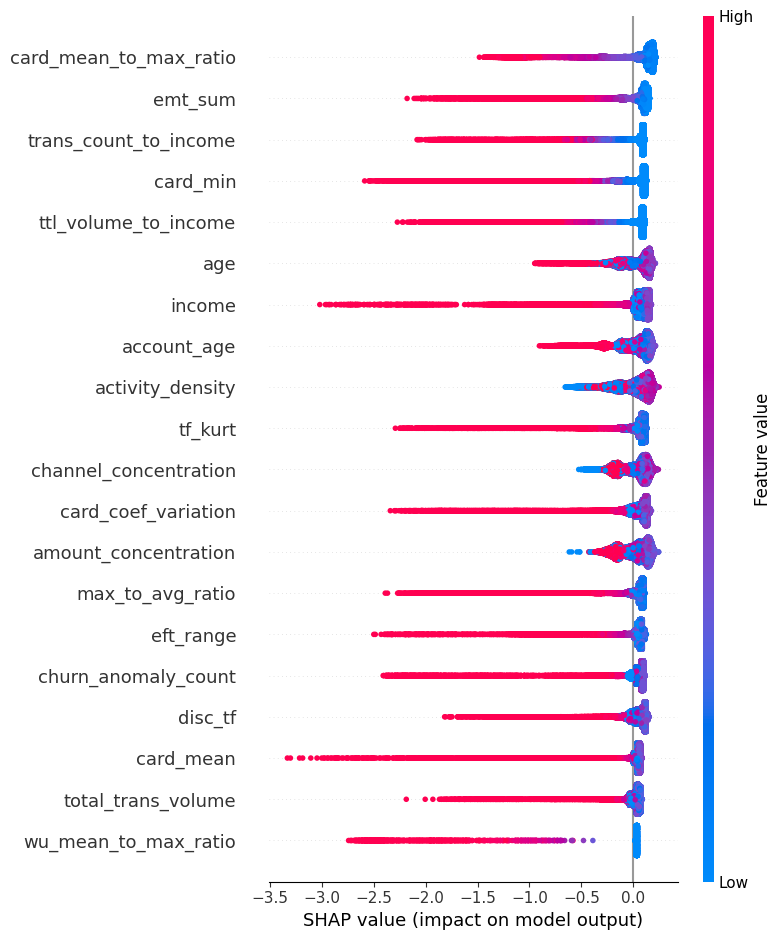

In [66]:
shap.summary_plot(shap_values, X)

### Isolation Forest for small business accounts

#### Model training

In [67]:
cols_to_keep = ['customer_id'] + business_important_features
business_features_selected = business_features[cols_to_keep].copy()
X = business_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 23
Customers: 7,641

Missing values: 0
Infinite values: 0


In [68]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.3s remaining:    3.4s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.5s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

#### Results

In [69]:
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

business_features_selected['raw_anomaly_score'] = raw_scores
business_features_selected['is_alerted'] = is_alerted
business_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
business_risk_score = business_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [70]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (business_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (business_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (business_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (business_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
business_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(business_risk_score['risk_level'].value_counts(normalize=True) * 100)
business_risk_score


Distribution of Risk Levels:
risk_level
Low       79.989530
Medium    14.998037
High       5.012433
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
32421,SYNID0200712083,100.000000,-0.207028,1,High
55946,SYNID0200159270,99.655791,-0.205764,1,High
44084,SYNID0200931678,97.550574,-0.198034,1,High
57938,SYNID0200161910,96.730065,-0.195021,1,High
26734,SYNID0200373751,96.397001,-0.193798,1,High
...,...,...,...,...,...
43043,SYNID0200623578,0.199749,0.159421,0,Low
28748,SYNID0200925888,0.102298,0.159779,0,Low
45784,SYNID0200640317,0.072737,0.159887,0,Low
59517,SYNID0200487702,0.049829,0.159972,0,Low


#### Model Performance

In [71]:
# Check the accuracy of isolation forest on our labelled data

print(business_risk_score[business_risk_score['customer_id'].isin(fraud_customers)])

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
22311  SYNID0200755995       38.616508           0.018362           0   
26568  SYNID0200496670       11.840679           0.116678           0   
43972  SYNID0200755574        9.022356           0.127026           0   
20217  SYNID0200187014        6.164757           0.137519           0   

      risk_level  
22311     Medium  
26568        Low  
43972        Low  
20217        Low  


#### Model explanation

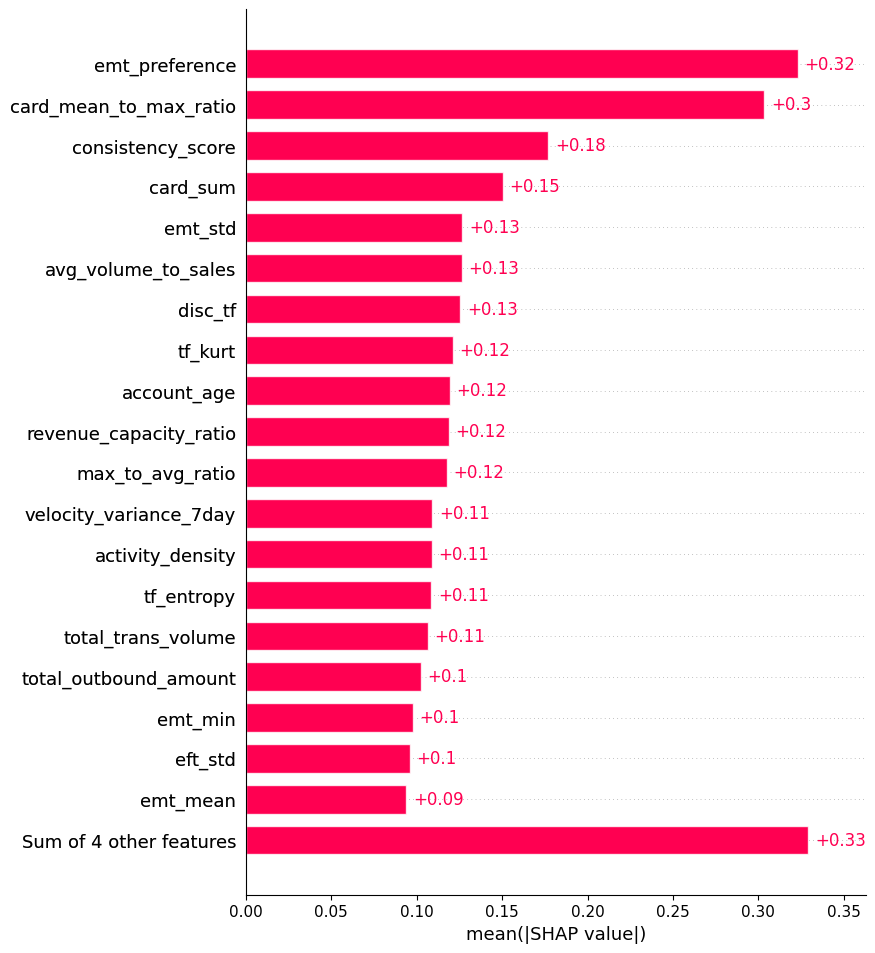

In [72]:
# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

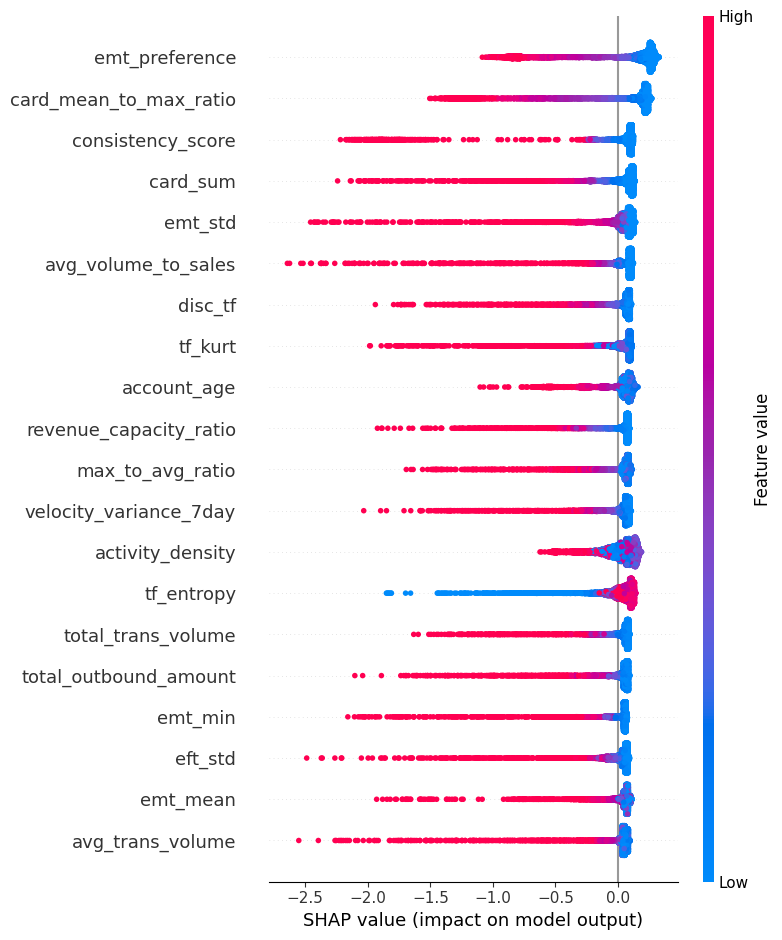

In [73]:
shap.summary_plot(shap_values, X)

In [74]:
business_risk_score.to_csv('business_accounts_risk_profile.csv',index=False)
individual_risk_score.to_csv('individual_accounts_risk_profile.csv',index=False)

## *** Isolation Forest Training (without feature selection through xgboost)

In [75]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

In [76]:
individual_features = features_reduced[features_reduced['customer_id'].isin(kyc_individual['customer_id'])].drop(columns=['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio','sales'])
business_features = features_reduced[features_reduced['customer_id'].isin(kyc_smallbusiness['customer_id'])].drop(columns=['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio','income','age'])

### Isolation Forest for individual accounts

In [77]:
individual_features_selected = individual_features.copy()
X = individual_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 60
Customers: 52,677

Missing values: 3493
Infinite values: 0


In [78]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.2s remaining:    2.1s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.3s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

In [79]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

individual_features_selected['raw_anomaly_score'] = raw_scores
individual_features_selected['is_alerted'] = is_alerted
individual_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
individual_risk_score = individual_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [80]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (individual_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (individual_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (individual_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (individual_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
individual_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(individual_risk_score['risk_level'].value_counts(normalize=True) * 100)
individual_risk_score


Distribution of Risk Levels:
risk_level
Low       79.998861
Medium    15.000854
High       5.000285
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
15835,SYNID0105890772,100.000000,-0.248261,1,High
30101,SYNID0105411519,96.717424,-0.235587,1,High
17013,SYNID0100264783,94.256908,-0.226087,1,High
20484,SYNID0103568592,91.155556,-0.214113,1,High
13137,SYNID0104466963,89.332420,-0.207074,1,High
...,...,...,...,...,...
34693,SYNID0105913342,0.386390,0.136345,0,Low
11030,SYNID0109919444,0.384979,0.136351,0,Low
24536,SYNID0106919464,0.280158,0.136755,0,Low
53494,SYNID0100453199,0.164074,0.137203,0,Low


In [81]:
# Check the accuracy of isolation forest on our labelled data

nonfraud_customers = labels[labels['label'] == 0]['customer_id'].unique()
fraud_customers = labels[labels['label'] == 1]['customer_id'].unique()
print(individual_risk_score[individual_risk_score['customer_id'].isin(fraud_customers)])
print('\n')

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
43910  SYNID0107464935       40.167839          -0.017250           1   
23583  SYNID0107334515       35.276440           0.001635           0   
130    SYNID0107832828       25.372126           0.039876           0   
56975  SYNID0101421130       21.451163           0.055014           0   
46573  SYNID0105593361       21.288002           0.055644           0   
56007  SYNID0100957188       16.657800           0.073521           0   

      risk_level  
43910       High  
23583     Medium  
130       Medium  
56975     Medium  
46573     Medium  
56007        Low  




at least many of our suspicious (labelled 1) accounts are labelled as medium-level risk

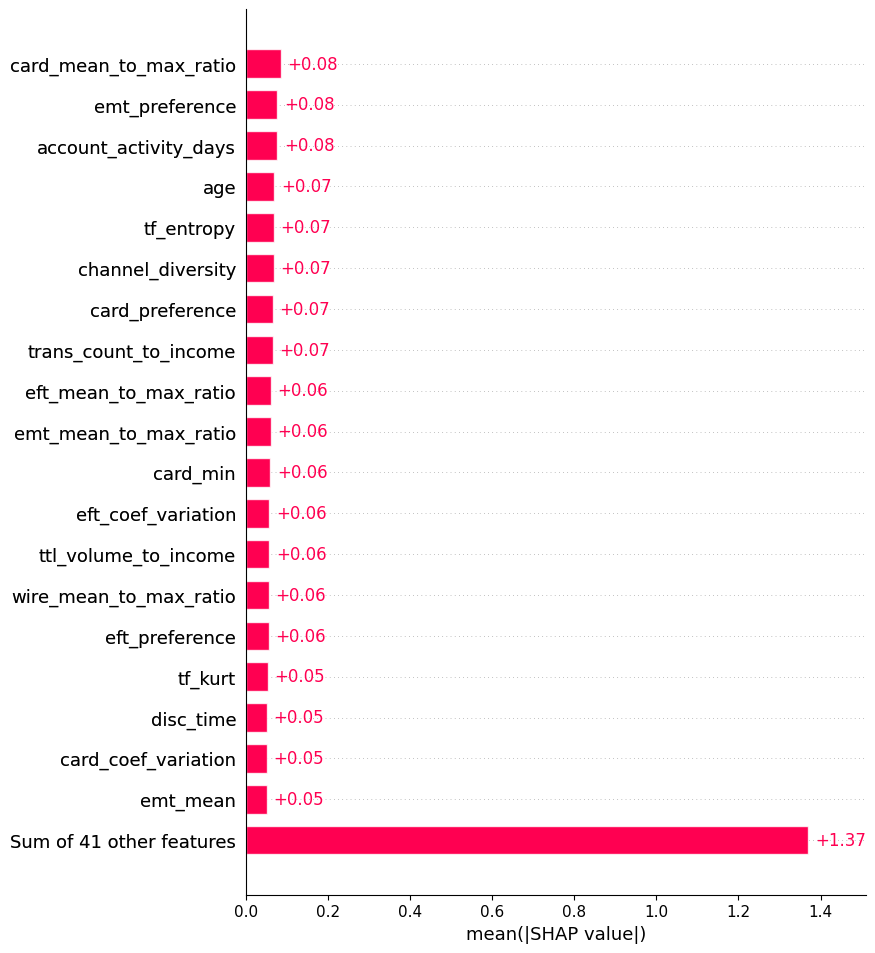

In [82]:
import shap

# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

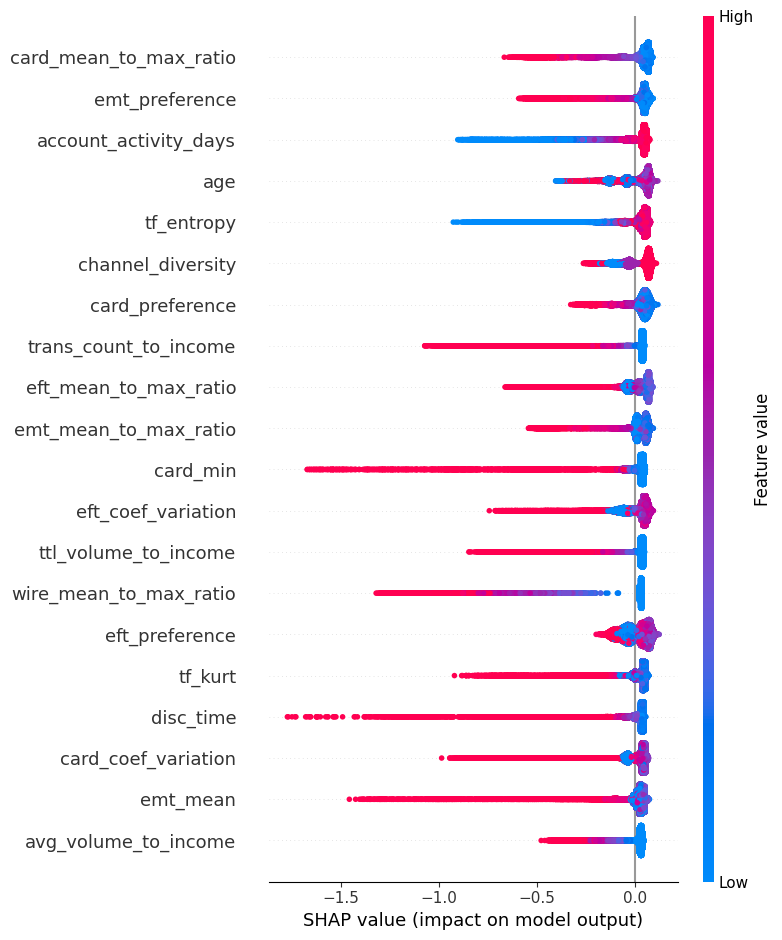

In [83]:
shap.summary_plot(shap_values, X)

### Isolation Forest for small business accounts

In [84]:
business_features_selected = business_features.copy()
X = business_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 59
Customers: 7,641

Missing values: 0
Infinite values: 0


In [85]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.1s remaining:    1.6s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.2s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

In [86]:
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

business_features_selected['raw_anomaly_score'] = raw_scores
business_features_selected['is_alerted'] = is_alerted
business_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
business_risk_score = business_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [87]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (business_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (business_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (business_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (business_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
business_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(business_risk_score['risk_level'].value_counts(normalize=True) * 100)
business_risk_score


Distribution of Risk Levels:
risk_level
Low       79.989530
Medium    14.998037
High       5.012433
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
45352,SYNID0200017800,100.000000,-0.192669,1,High
6626,SYNID0200263267,98.806898,-0.188612,1,High
55946,SYNID0200159270,98.332875,-0.187000,1,High
41157,SYNID0200837172,97.000180,-0.182468,1,High
22677,SYNID0200639063,96.911255,-0.182166,1,High
...,...,...,...,...,...
50713,SYNID0200118356,0.207347,0.146679,0,Low
42013,SYNID0200696505,0.178288,0.146778,0,Low
25679,SYNID0200963949,0.167504,0.146815,0,Low
16680,SYNID0200897279,0.135624,0.146923,0,Low


In [88]:
# Check the accuracy of isolation forest on our labelled data

print(business_risk_score[business_risk_score['customer_id'].isin(fraud_customers)])

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
22311  SYNID0200755995       23.673598           0.066881           0   
43972  SYNID0200755574       16.025715           0.092888           0   
20217  SYNID0200187014       12.239955           0.105762           0   
26568  SYNID0200496670        8.025555           0.120093           0   

      risk_level  
22311        Low  
43972        Low  
20217        Low  
26568        Low  


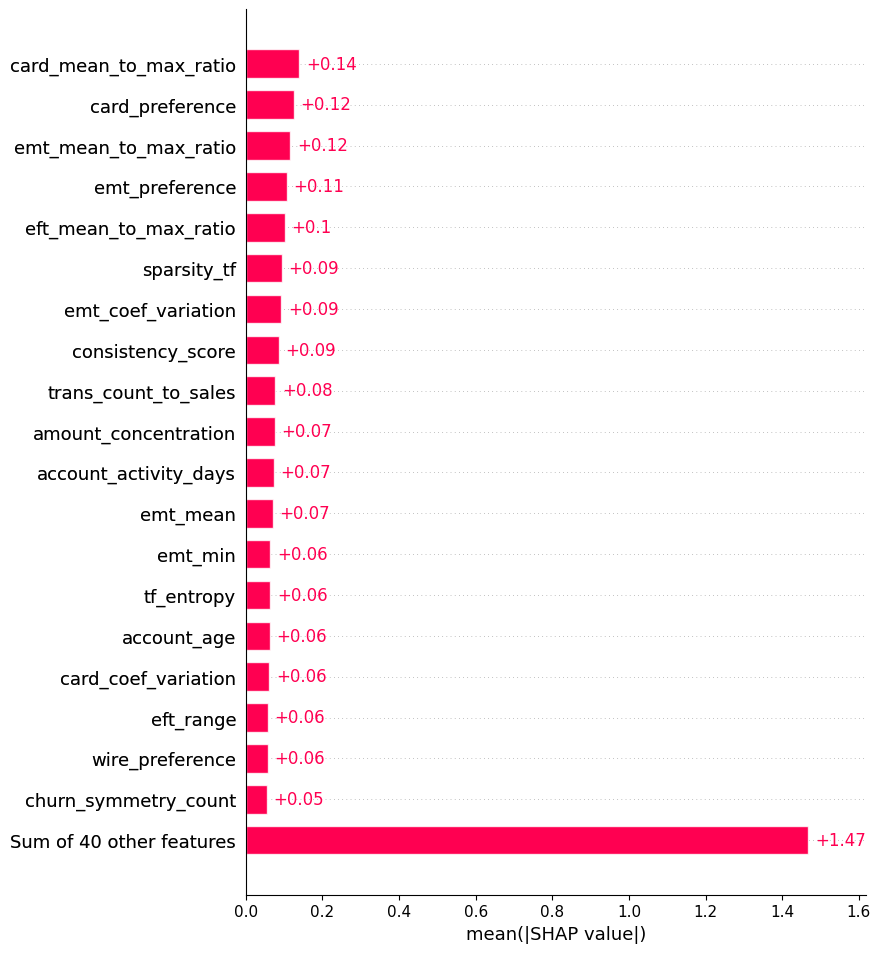

In [89]:
# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

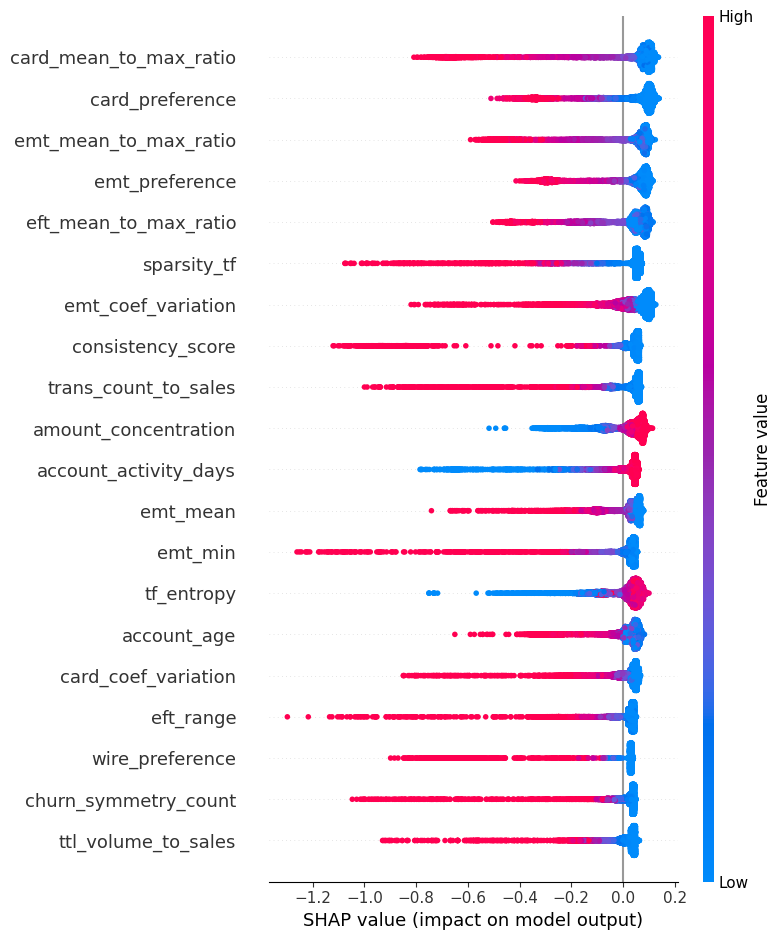

In [90]:
shap.summary_plot(shap_values, X)